In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/cherngs/heart-disease-cleveland-uci/heart_cleveland_upload.csv


In [2]:
#import
import numpy as np
import pandas as pd
import joblib

In [3]:
#load the dataset
df=pd.read_csv("/kaggle/input/datasets/cherngs/heart-disease-cleveland-uci/heart_cleveland_upload.csv")

In [4]:
# Dataset Overview
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,2.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,0.602694,0.676768,0.835017,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,0.956690,0.499340
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,0.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,2.000000,1.000000


In [5]:
#Check missing and duplicates
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

## Data Cleaning

The dataset was checked for missing values and duplicate records.

Results:
- No missing values were found in any column.
- No duplicate rows were detected.

Therefore, no imputation or duplicate removal was required. The dataset is clean and ready for exploratory data analysis.


## Exploratory Data Analysis (EDA)

EDA is performed to understand the distribution of variables, detect outliers, and examine relationships between features and the target variable.


In [6]:
#Import visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
#set style
sns.set_style("whitegrid")

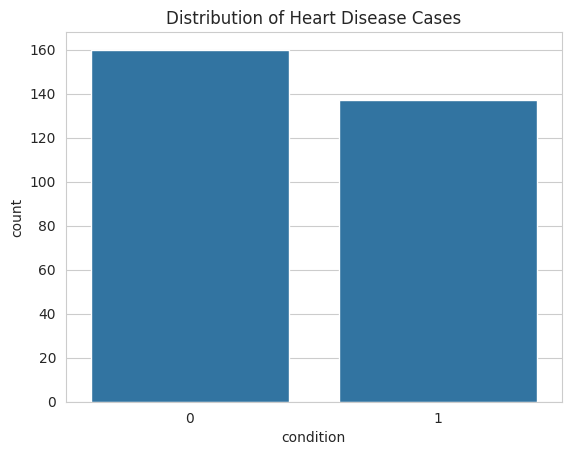

condition
0    160
1    137
Name: count, dtype: int64

In [8]:
# Distribution of Target Variable
sns.countplot(x='condition', data=df)
plt.title("Distribution of Heart Disease Cases")
plt.show()

df['condition'].value_counts()

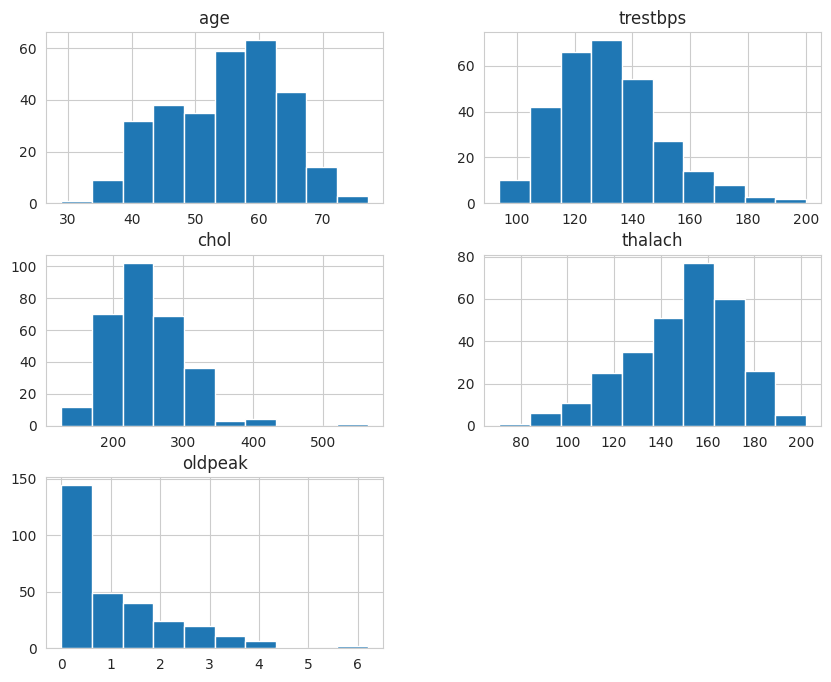

In [9]:
# Distribution of Numerical Features
num_cols = ['age','trestbps','chol','thalach','oldpeak']

df[num_cols].hist(figsize=(10,8))
plt.show()

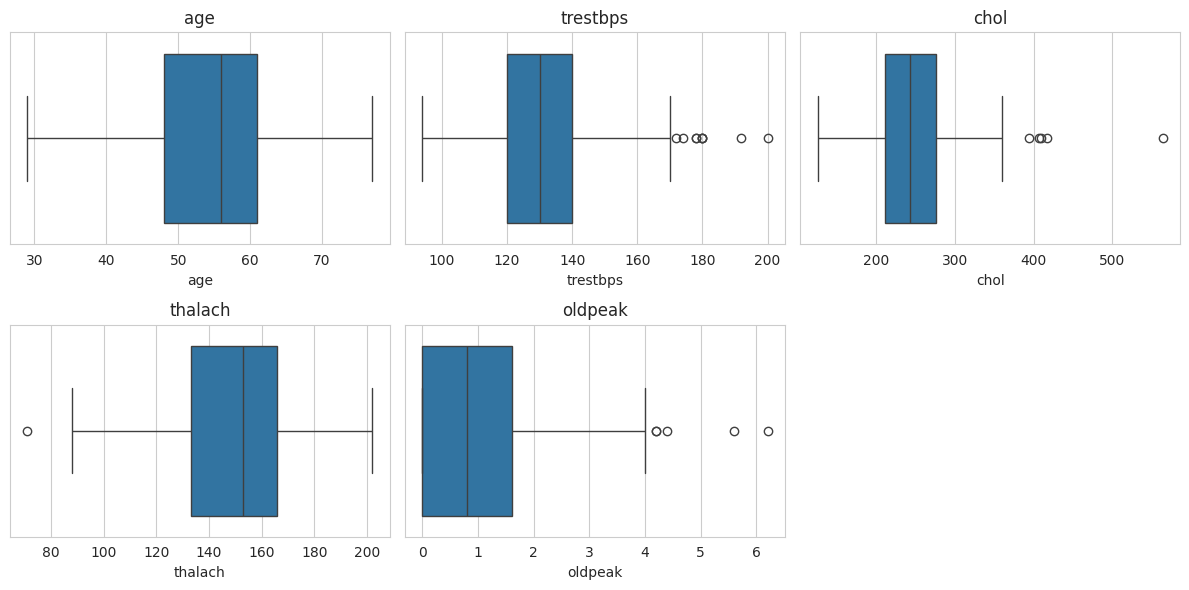

In [10]:
# Outlier Detection using Boxplots
plt.figure(figsize=(12,6))
for i,col in enumerate(num_cols):
    plt.subplot(2,3,i+1)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

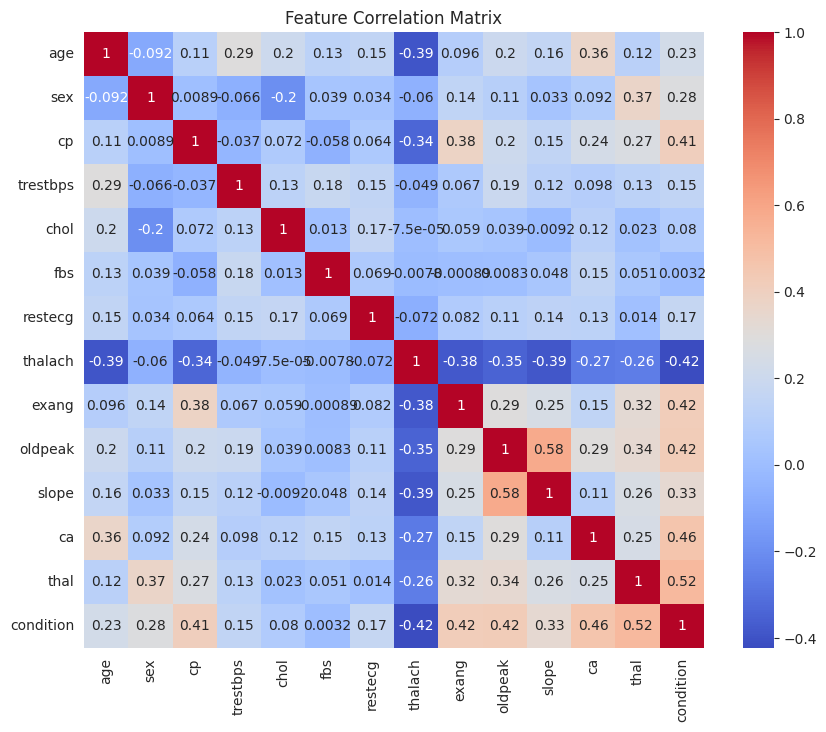

In [11]:
# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

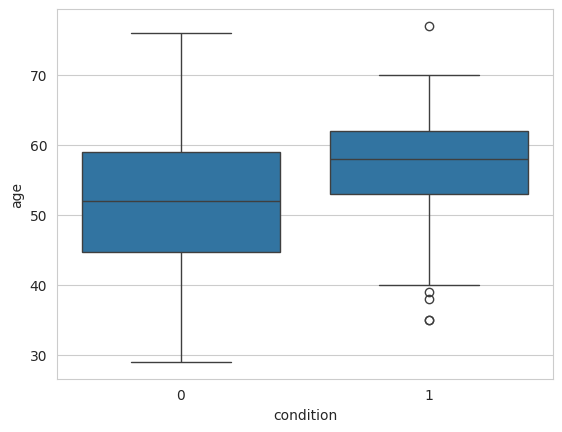

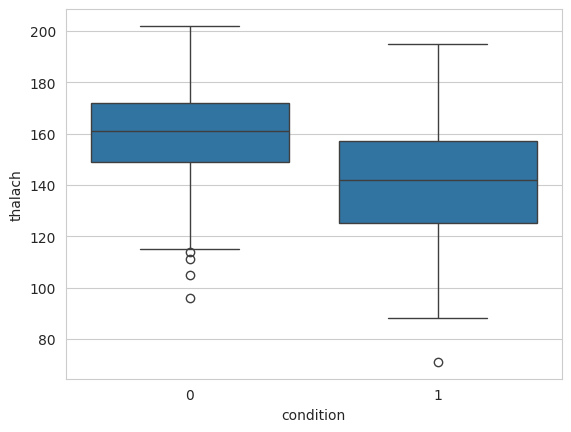

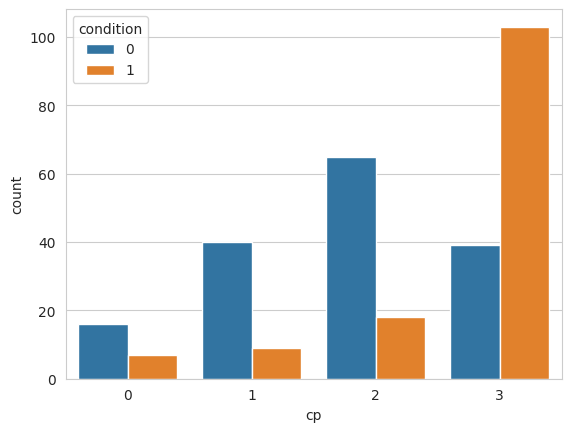

In [12]:
# Feature Relationship with Heart Disease
sns.boxplot(x='condition', y='age', data=df)
plt.show()

sns.boxplot(x='condition', y='thalach', data=df)
plt.show()

sns.countplot(x='cp', hue='condition', data=df)
plt.show()

### Target Variable Balance

The dataset contains:
- 160 instances without heart disease
- 137 instances with heart disease

This indicates that the dataset is relatively balanced. Therefore, no class imbalance handling techniques such as oversampling or undersampling are required.

In [13]:
# Feature and Target Separation
X = df.drop('condition', axis=1)
y = df['condition']

In [14]:
#Confirm the shapes
X.shape
y.shape

(297,)

In [15]:
X.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
dtype: object

## Feature Encoding

All categorical variables in the dataset are already numerically encoded. Therefore, no additional encoding techniques such as One-Hot Encoding or Label Encoding were required.

In [16]:
# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Feature Scaling

Feature scaling is applied to standardize numerical variables so that they have a mean of 0 and a standard deviation of 1. This improves the performance of algorithms such as Logistic Regression that are sensitive to feature magnitude.

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Training
Two baseline machine learning models are trained for comparison:
1. Logistic Regression
2. Random Forest Classifier

In [18]:
#Train Logistics regression
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()

log_reg.fit(X_train_scaled, y_train)

LogisticRegression()

In [19]:
#train random forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

## Model Predictions
Predictions are generated using the trained models on the test dataset.

In [20]:
log_pred = log_reg.predict(X_test_scaled)
rf_pred = rf.predict(X_test_scaled)

log_prob = log_reg.predict_proba(X_test_scaled)[:,1]
rf_prob = rf.predict_proba(X_test_scaled)[:,1]

## Model Evaluation
Models are evaluated using F1-score and ROC-AUC, which are appropriate metrics for binary classification problems.

In [28]:
from sklearn.metrics import f1_score, roc_auc_score

log_f1 = f1_score(y_test, log_pred)
rf_f1 = f1_score(y_test, rf_pred)

log_auc = roc_auc_score(y_test, log_prob)
rf_auc = roc_auc_score(y_test, rf_prob)

print("Logistic Regression F1:", log_f1)
print("Random Forest F1:", rf_f1)

print("Logistic Regression ROC-AUC:", log_auc)
print("Random Forest ROC-AUC:", rf_auc)

Logistic Regression F1: 0.7241379310344828
Random Forest F1: 0.6896551724137931
Logistic Regression ROC-AUC: 0.8415178571428571
Random Forest ROC-AUC: 0.84765625


In [29]:
from sklearn.metrics import accuracy_score

accuracy_lr = accuracy_score(y_test, log_pred)
accuracy_rf = accuracy_score(y_test, rf_pred)

print("Logistic Regression Accuracy:", accuracy_lr)
print("Random Forest Accuracy:", accuracy_rf)

Logistic Regression Accuracy: 0.7333333333333333
Random Forest Accuracy: 0.7


## Model Comparison and Selection

Two models were evaluated: Logistic Regression and Random Forest.

Results:

Logistic Regression  
F1-score: 0.724  
ROC-AUC: 0.842  

Random Forest  
F1-score: 0.690  
ROC-AUC: 0.848  

Although Random Forest achieved a slightly higher ROC-AUC, Logistic Regression produced a higher F1-score. Since F1-score balances precision and recall and is important in medical prediction tasks, Logistic Regression was selected as the final model.

In [22]:
import pickle

pickle.dump(log_reg, open("heart_disease_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

### Confusion Matrix
The confusion matrix shows the number of correct and incorrect predictions made by the model.

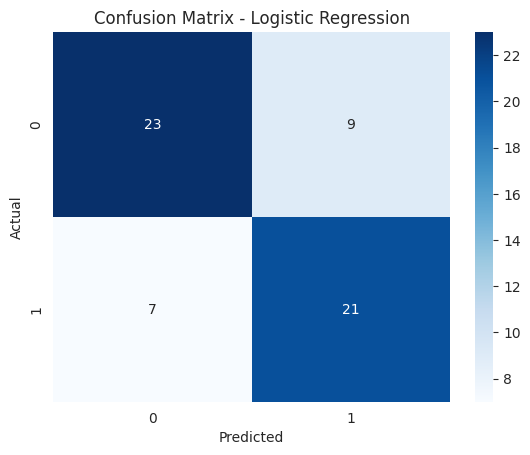

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, log_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [24]:
predictions = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': log_pred
})

predictions.head(10)

,Actual,Predicted
0,1,1
1,1,1
2,0,0
3,0,0
4,0,1
5,0,0
6,1,1
7,1,1
8,0,1
9,0,0


In [25]:
predictions_with_prob = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': log_pred,
    'Probability_of_Disease': log_prob
})

predictions_with_prob.head(10)

,Actual,Predicted,Probability_of_Disease
0,1,1,0.857081
1,1,1,0.781823
2,0,0,0.352590
3,0,0,0.007296
4,0,1,0.702826
5,0,0,0.131457
6,1,1,0.996289
7,1,1,0.996794
8,0,1,0.977803
9,0,0,0.113701


In [26]:
import pickle

with open("heart_model.pkl", "wb") as f:
    pickle.dump(log_reg, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [30]:
df.shape

(297, 14)

In [27]:
#test the model manually
import pandas as pd

sample_input = pd.DataFrame([{
    "age": 52,
    "sex": 1,
    "cp": 2,
    "trestbps": 130,
    "chol": 250,
    "fbs": 0,
    "restecg": 1,
    "thalach": 160,
    "exang": 0,
    "oldpeak": 1.2,
    "slope": 1,
    "ca": 0,
    "thal": 2
}])

sample_scaled = scaler.transform(sample_input)

prediction = log_reg.predict(sample_scaled)[0]
probability = log_reg.predict_proba(sample_scaled)[0][1]

print("Prediction:", prediction)
print("Probability of heart disease:", probability)

Prediction: 1
Probability of heart disease: 0.6104180577926809


## Model Evaluation Summary

Two machine learning models were trained to predict the presence of heart disease:

1. Logistic Regression  
2. Random Forest Classifier

Both models were evaluated using Accuracy, F1-score, and ROC-AUC.

### Logistic Regression Performance
Accuracy: 73.33%  
F1-score: 0.724  
ROC-AUC: 0.842  

### Random Forest Performance
Accuracy: 70.00%  
F1-score: 0.690  
ROC-AUC: 0.848  

### Interpretation

Accuracy measures the proportion of correct predictions made by the model. Logistic Regression achieved the highest accuracy (73.33%), indicating it correctly classified more patients overall.

The F1-score evaluates the balance between precision and recall, which is important for medical prediction tasks where both false positives and false negatives matter. Logistic Regression also produced the higher F1-score (0.724), indicating better classification performance.

ROC-AUC measures the model’s ability to distinguish between patients with and without heart disease. Both models performed well, with Random Forest slightly outperforming Logistic Regression (0.848 vs 0.842). However, the difference is minimal.

### Final Model Selection

Although Random Forest achieved a marginally higher ROC-AUC, Logistic Regression was selected as the final model because it achieved the highest Accuracy and F1-score, indicating better overall classification performance for this task.

### Final Selected Model
Logistic Regression